## Pre-processing datapoints
performing per processing operations required to further clean the dataset.

In [1]:
# import necessary lib's

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading updated file

In [2]:
FILE_PATH=r'E:\45DaysML\projects\Fraud-detection\dataset\preprocessed\updated_dataset.csv'
chunk_size=100_000
results=[]

with pd.read_csv(FILE_PATH, chunksize=chunk_size) as raw_dataset:
    for chunk in raw_dataset:
        results.append(chunk)

df = pd.concat(results, ignore_index=True)

### Visualizing the data distribution

as we previously checked in our previous step, the data is highly **imbalanced** we can clearly see that the same observation in the below given graph as well, here i'm plotting the same graph which i did before.

<Axes: xlabel='isFraud'>

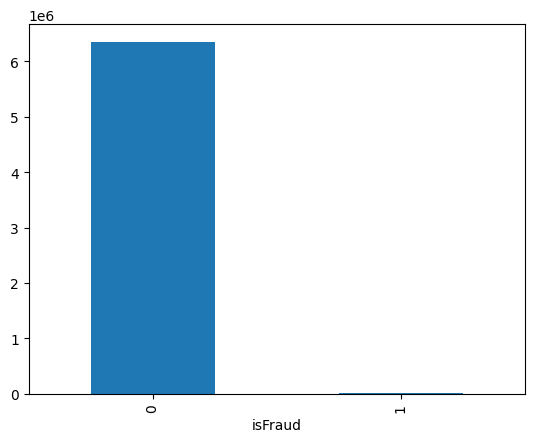

In [3]:
df['isFraud'].value_counts().plot(kind='bar')

For handling this **imbalanced** classification we decided to go with the **weight assignment** strategy.

before going any further remove the `Unnamed: 0` column from the above dataset.

In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)

### Check if there is any missing values in the dataset or not.

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

From the above results we can clearly see that there is no missing values in the given dataset.

### Checking for outliers 

<Axes: xlabel='type', ylabel='amount'>

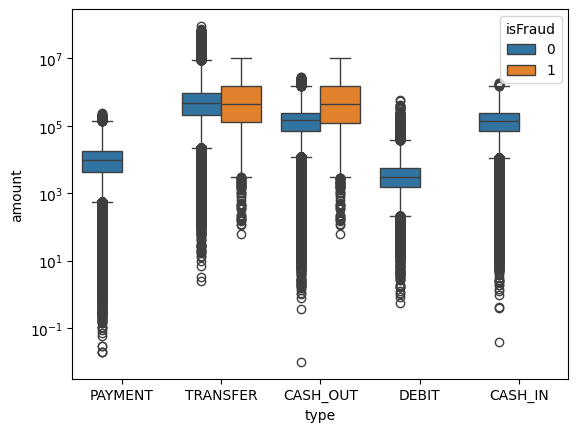

In [6]:
plt.yscale('log')
sns.boxplot(data=df, x='type', y='amount', hue='isFraud')

<Axes: ylabel='amount'>

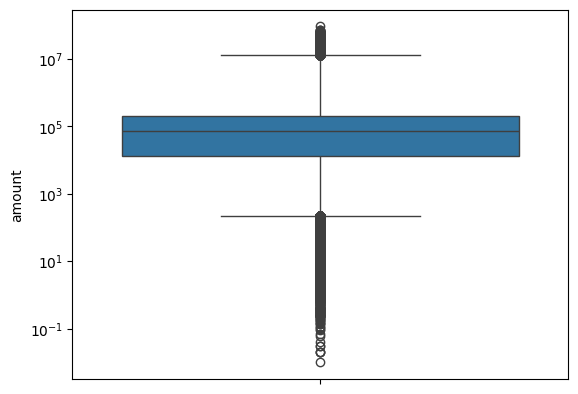

In [7]:
plt.yscale('log')
sns.boxplot(data=df, y='amount')

In [8]:
q1 = df.amount.quantile(0.25)
q2 = df.amount.quantile(0.75)

iqr = q2-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q2 + 1.5*iqr

outliers = df[ (df.amount < lower_bound) | (df.amount > upper_bound) ]

In [9]:
print("Total no. of outliers: ", outliers.shape[0])

Total no. of outliers:  338078


### Checking for multi-collinearity

<Axes: >

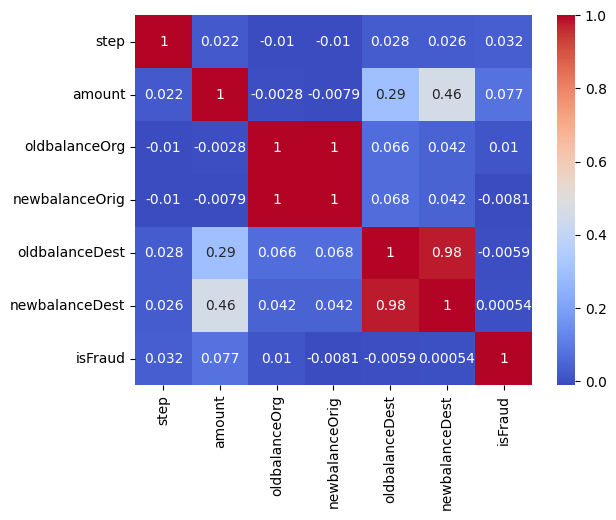

In [10]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

From the above *heatmap* we can clearly see that, some columns are highly correlated with each others, specially the columns which are *red* in color. so for handling this **multi collinearity** scenario, we're perform *feature engineering*.

**What new Feature Engineered?**
+ We create a new feature named as `sender_balance_difference` which is calculated by subtracting `oldbalanceOrg` from `newblanaceOrig`.
+ Similarly, we create another feature named as `receiver_balance_difference` which is calculated by subtracting `newbalanceDest` from `oldbalanceDest`.
+ Also, we can create the scaled transaction feature for both *sender* and *receiver*. this will represent if, huge money transfers are there in the system this means, high chances of **Fraud Txn**.
<br/>
After, we'll drop all the 4 columns.

In [11]:
# create new features

df['sender_balance_difference'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_difference'] = df['newbalanceDest'] - df['oldbalanceDest']

In [12]:
df['amount_over_sender'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['amount_over_receiver'] = df['amount'] / (df['oldbalanceDest'] + 1)

In [13]:
# drop redundant features

df.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], inplace=True)

**checking for multi-collineartiy again**

<Axes: >

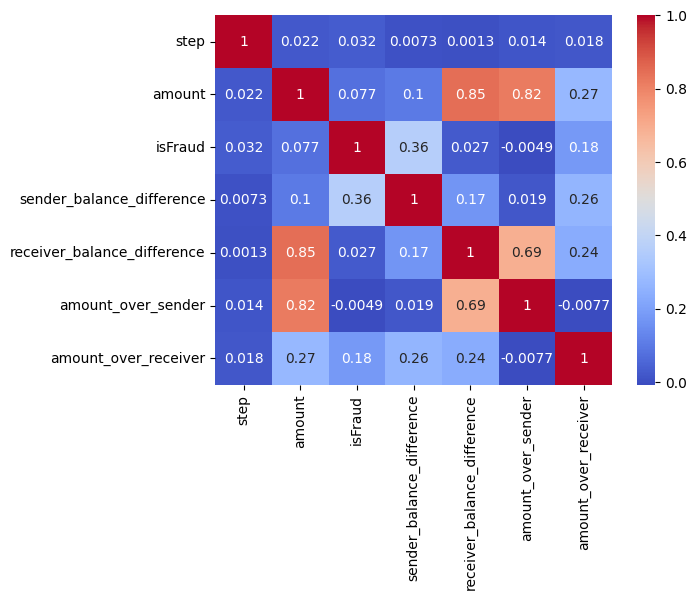

In [14]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

As we can clearly see now, this looks much better, since we removed all 4 correlated columns, but there is still one column that is `amount` which is highly correlated with column `receiver_balance_difference`.

**Should we remove then**: 
**No**, they are correlated because `receiver_balance_difference` show the amount which is received by the receiver, which is approx. equals to `amount` sent by the sender. that's why there is a correlation. they both tells difference meaning, so we do not remove these columns.

In [15]:
print("Remaining columns in the updated_dataset.csv file: ", df.columns) 

Remaining columns in the updated_dataset.csv file:  Index(['step', 'type', 'amount', 'isFraud', 'sender_balance_difference',
       'receiver_balance_difference', 'amount_over_sender',
       'amount_over_receiver'],
      dtype='object')


We previously dropped this column, therefore creating the same column here again.

In [16]:
df['is_large_transaction'] = (df['amount'] > 200_000).astype(int)

### Save this dataframe object

In [18]:
df.to_csv(r"E:\45DaysML\projects\Fraud-detection\dataset\preprocessed\updated_dataset001.csv")